# Clinical Notes Analysis – NER & Medical specialty Classification, Part 2
**Author:** Maria Kalimeri  
**Domain:** Clinical Text Classification  
**Date:** November/December 2025

---

## 1. Introduction
In the second part of this project, I will use the dataset produced in Part I, which contains the extracted entities from clinical notes and their UMLS CUIs to classify patient records into medical expertise.  

**Goals:**
- Medical specialty classification
- Visualisation of insights

---

First, we need to import the necessary libraries. The installation of the libraries has been performed in a dedicated conda environment (see README.md). **If the environment has not been created yet, do this before continuing!**

In [19]:
# Imports

from collections import defaultdict
from environs import Env
from pathlib import Path
import sys
sys.path.append("..")
from typing import Dict

import textwrap

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import boto3

from helpers.helpers import get_environment_variables


In [20]:
# Version installed
print("Python executable:", sys.executable)


Python executable: /Users/mariakalimeri/opt/anaconda3/envs/analysis_env/bin/python


## 2. Dataset

The dataset I am using was created in the previous step  and it contains medical transcription text, entities and the corresponding ULMS CUIs, as well as the medical specialty relevant to the transcription.


In [21]:
# Get the dataset
file_path = "../data/processed/CUI_medicalSpecialties.parquet"
transcriptionsall_df = pd.read_parquet(file_path)

transcriptionsall_df.sample(10)

,transcript_id,medical_specialty,CUI,transcription
2101,2102,Orthopedic,"[C0008947, C0016658, C0015806, C0043242, C0476...","TITLE OF OPERATION:,1. Open reduction interna..."
2760,2761,Neurology,"[C0332459, C0019080, C0340766, C0030193]","PREOPERATIVE DIAGNOSIS: , Chronic venous hyper..."
270,271,Surgery,"[C2945665, C0019080, C0031354]","PREOPERATIVE DIAGNOSIS:, Chronic tonsillitis...."
2841,2842,Neurology,[],"FINDINGS:,There is a large intrasellar mass le..."
781,782,Surgery,"[C0028778, C1704272, C0005695, C0023660]","PREOPERATIVE DIAGNOSIS: , Microscopic hematuri..."
4256,4257,Consult - History and Phy.,"[C0011847, C0751265, C0392348, C0036202, C0016...","REASON FOR REFERRAL:, The patient is a 58-yea..."
176,177,Urology,[],Initially a small incision was made in the rig...
728,729,Surgery,[],"PROCEDURE PERFORMED,1. Placement of a subclav..."
1351,1352,SOAP / Chart / Progress Notes,"[C0011847, C0041582, C0240066, C0162373, C0333...","PRINCIPAL DIAGNOSES:,1. A 61-year-old white m..."
3525,3526,Gastroenterology,"[C0004057, C0015733, C0149931, C0018834, C0028...","PROBLEM: ,Prescription evaluation for Crohn's..."


For our purposes, we will only use columns medical_specialty and CUI, so I will remove the rest.

In [22]:
transcriptionsall_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4966 entries, 0 to 4998
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   transcript_id      4966 non-null   int64   
 1   medical_specialty  4966 non-null   category
 2   CUI                4966 non-null   object  
 3   transcription      4966 non-null   object  
dtypes: category(1), int64(1), object(2)
memory usage: 161.4+ KB


In [23]:
columns_to_keep = ['medical_specialty', 'CUI']

transcriptions_df = transcriptionsall_df[columns_to_keep]
transcriptions_df.head()

,medical_specialty,CUI
0,Allergy / Immunology,"[C0594492, C0162723, C0020517, C0667848, C0065..."
1,Bariatrics,"[C0011847, C0004238, C0013604, C0013404, C0019..."
2,Bariatrics,"[C0011847, C0004238, C0001962, C0013404, C0033..."
3,Cardiovascular / Pulmonary,"[C0238705, C0034088]"
4,Cardiovascular / Pulmonary,"[C4284103, C0013687, C2973725, C0003507, C1332..."


## 3. Initial Data Exploration

### Check data types, missing values

In [24]:
print(f"The dataset consists of {transcriptions_df.shape[0]} rows")

The dataset consists of 4966 rows


In [25]:
transcriptions_df.dtypes

medical_specialty    category
CUI                    object
dtype: object

### Look for empty CUI lists/medical specialties

It is possible that an entry is not null, but still contains values. Let's see if this is the case for medical specialties or CUI lists.

In [26]:
transcriptions_df['length_medical_specialty'] = transcriptions_df.medical_specialty.apply(lambda x: len(x))
transcriptions_df['length_cui'] = transcriptions_df.CUI.apply(lambda x: len(x))
transcriptions_df.sample(10)

/var/folders/h3/nfz97p4s4nbfn9k6j6f6cknh0000gn/T/ipykernel_2422/3370189612.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transcriptions_df['length_medical_specialty'] = transcriptions_df.medical_specialty.apply(lambda x: len(x))


,medical_specialty,CUI,length_medical_specialty,length_cui
3109,Hospice - Palliative Care,"[C0917801, C0013604, C0013404, C0035078, C0029...",26,29
365,Surgery,"[C2945665, C0483514, C0030193]",8,3
3011,Nephrology,"[C0023660, C0016169, C0700926, C0032483, C0678...",11,7
4295,Consult - History and Phy.,"[C0011847, C0036439, C0037366, C0004093, C0020...",27,23
4595,Consult - History and Phy.,"[C0031350, C0006271, C0015967, C0010520, C0004...",27,16
3809,Emergency Room Reports,"[C0127096, C0020261, C0037366, C0003864, C0018...",23,6
1303,SOAP / Chart / Progress Notes,"[C0003507, C0004238, C0013404]",30,3
3084,Lab Medicine - Pathology,"[C0007120, C0019080, C0027651, C0027540]",25,4
431,Surgery,"[C0332663, C0270611, C0575059, C0008196, C0031...",8,5
3484,Gastroenterology,"[C0011847, C0022346, C0007012, C0037473, C0020...",17,21


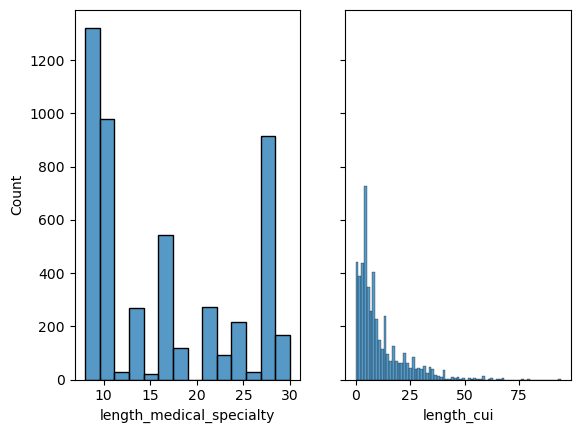

In [27]:
fig, ax = plt.subplots(1,2, sharey=True)
sns.histplot(data=transcriptions_df, x="length_medical_specialty", ax=ax[0])
sns.histplot(data=transcriptions_df, x="length_cui", ax=ax[1])
fig.suptitle = "Length of text in medical specialties and CUI lists"
plt.show()

In [28]:
print(f"The average CUI list consists of {np.round(transcriptions_df['length_cui'].mean())} CUIs \n")
print(f"There are {transcriptions_df[transcriptions_df['length_cui'] == 0].shape[0]} empty CUI lists in the dataset")

The average CUI list consists of 11.0 CUIs 

There are 181 empty CUI lists in the dataset


So, there is a number of empty CUI lists in the dataset. Before we drop these, lets's see what medical specialties they belong to.

In [29]:
transcriptions_df['no_cui'] = transcriptions_df.length_cui.apply(lambda x: True if x==0 else False)
transcriptions_df.sample(5)

,medical_specialty,CUI,length_medical_specialty,length_cui,no_cui
756,Surgery,"[C0012963, C0149746, C0023660, C0030054, C0002...",8,9,False
3512,Gastroenterology,"[C2945665, C0030193, C0003615]",17,3,False
391,Surgery,"[C0023660, C2945665, C0057476]",8,3,False
583,Surgery,"[C0018944, C0023267]",8,2,False
153,Urology,"[C0023660, C0032857]",8,2,False


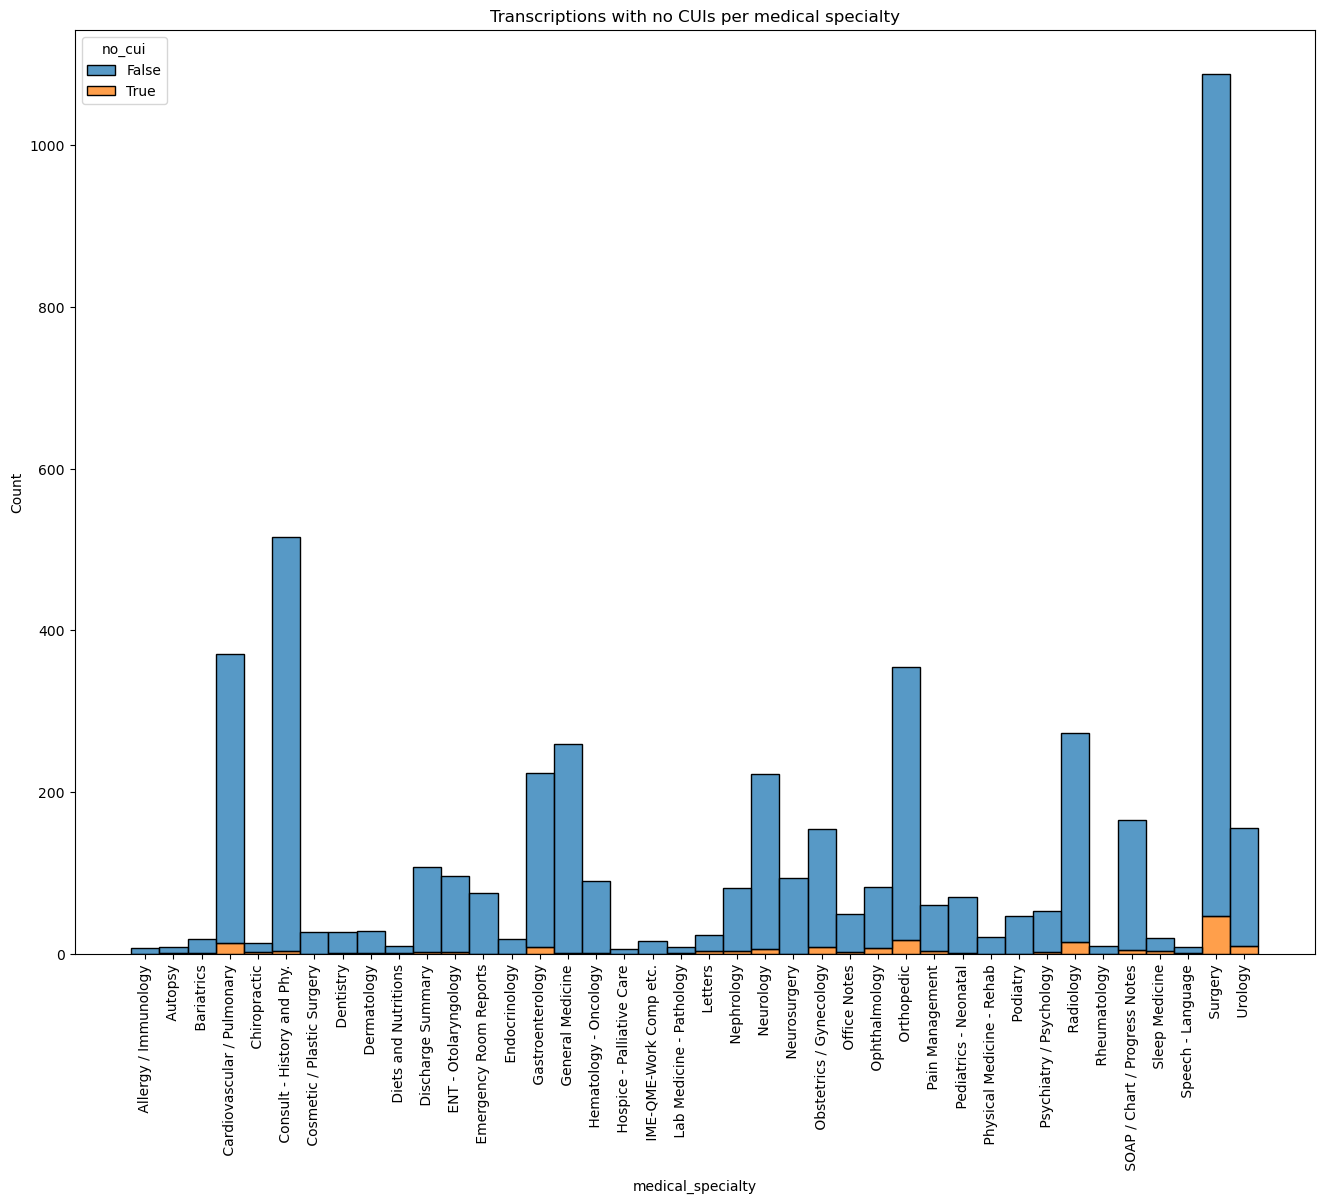

In [30]:
fig, ax = plt.subplots(figsize=(16,12))
sns.histplot(data=transcriptions_df, x='medical_specialty', multiple='stack', hue='no_cui')
ax.tick_params(axis='x', labelrotation=90)
ax.set_title("Transcriptions with no CUIs per medical specialty")
plt.show()

In the histogram above we can see that the transcriptions that do not contain any CUIs are relatively evenly distributed among medical specialties, so itis safe to remove them.

In [31]:
transcriptions_df = transcriptions_df[transcriptions_df.no_cui == False].reset_index()
transcriptions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4785 entries, 0 to 4784
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   index                     4785 non-null   int64   
 1   medical_specialty         4785 non-null   category
 2   CUI                       4785 non-null   object  
 3   length_medical_specialty  4785 non-null   int64   
 4   length_cui                4785 non-null   int64   
 5   no_cui                    4785 non-null   bool    
dtypes: bool(1), category(1), int64(3), object(1)
memory usage: 160.4+ KB


## 4. Exploratory Data Analysis (EDA)

### Average number of CUIs per medical specialty

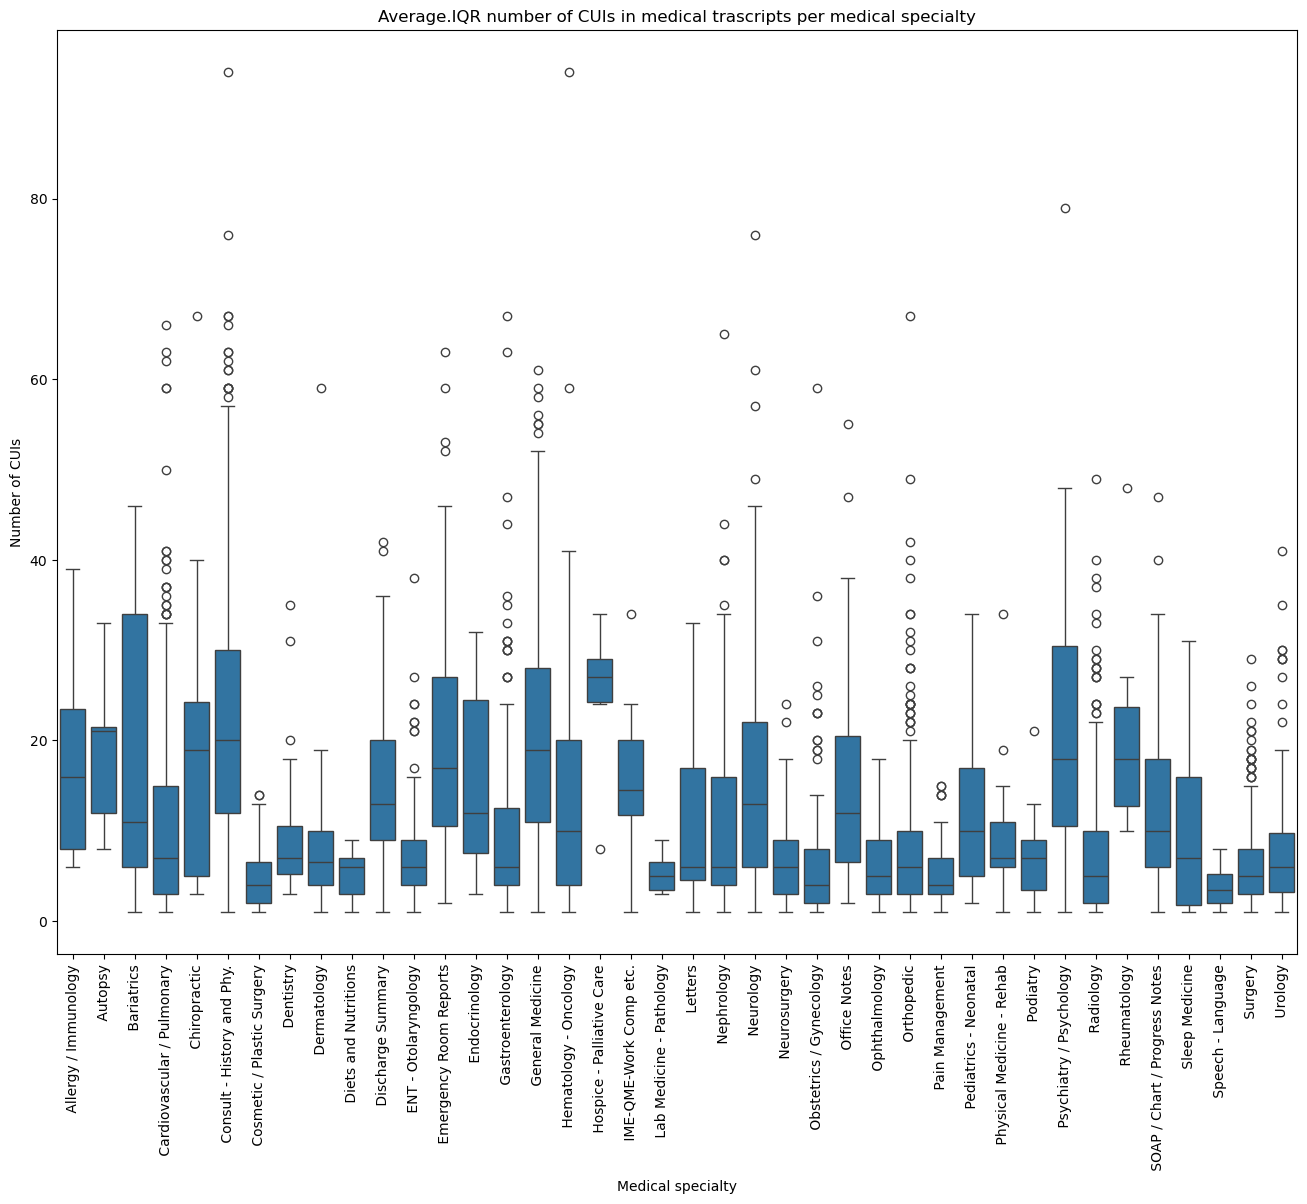

In [32]:
fig, ax = plt.subplots(figsize=(16,12))
sns.boxplot(data=transcriptions_df, x='medical_specialty', y='length_cui')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Medical specialty')
ax.set_ylabel('Number of CUIs')
ax.set_title('Average.IQR number of CUIs in medical trascripts per medical specialty')
plt.show()

We can see from the plot above that the average number of CUIs, as well as thei quartiles, vary among medical specialties. Notes taken for specialties such as Psycology and General Medicine contain, in average, a higher number of recognised medical entities, while others such as Surgery and Dentistry contain a lower number of recgnised medical entities. Some specialties are also associated with a large IQR (e.g. Bariatrics) while most also are associated with a large number of outliers.

### Class sizes

It should also be pointed out that close to half the medical specialties only have a few transcripts - the dataset is very imbalanced. Surgery is associated with about 25% of all the transcripts, while many other specialties only have a handful of transcripts (e.g. Allergy). 

If we assume that to train a classifier we need at least 50 data points per class, let's see how many classes clear this limit.

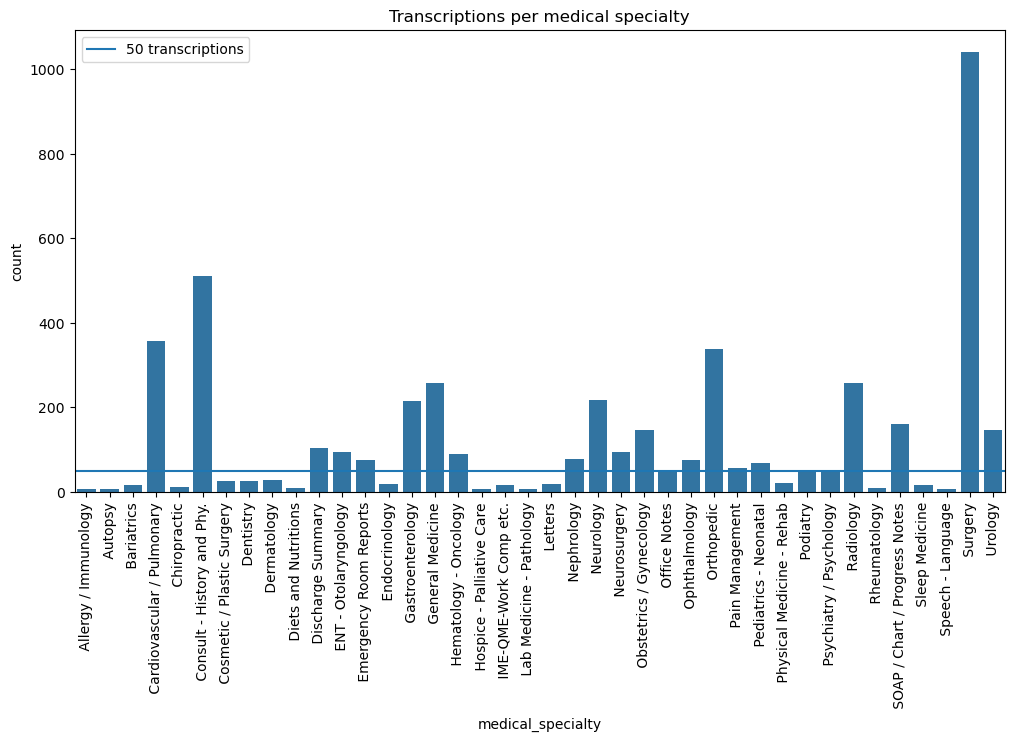

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(data=transcriptions_df, x="medical_specialty", ax=ax)
plt.axhline(y=50, label='50 transcriptions')
ax.tick_params(axis='x', labelrotation=90)
ax.set_title("Transcriptions per medical specialty")
plt.legend()
plt.show()

## 5. Feature engineering

We saw earlier that each data point is associated with a number of CUIs. This number lies roughly in the 1-100 range. In order to train a classifier, we would need to treat the CUIs as categorical variables and have each one be an input to the classifier. This means that we would have a classifier with almost 4000 inputs, which is close to the number of data points we have in the data set. This would not result in a reliable classifier.

In [34]:
all_cuis = set(transcriptions_df.explode(column='CUI').CUI)

print(f'There are {len(all_cuis)} CUIs in the dataset')

There are 3759 CUIs in the dataset


A way to decrease the dimensionality of the model would be to project the CUIs into a vector space. In NLP, a vector space is a mathematical model that represents text (words, sentences, or documents) as numerical vectors. By converting text into vectors in a high-dimensional space, NLP algorithms can perform tasks like calculating semantic similarity and information retrieval by measuring the geometric distance between these vectors. Such vector spaces in NLP are word2vec and GloVe, which have been created by using large amounts of text as train data. 

A conventional vector space would not be appropriate for our purposes, since it is not specific to our input, which consists exclusively of CUIs, that are a sequence of letters and numbers, e.g. C0027051 (Myocardial infarction). Thankfully, a relevant embedding exists, and it is CUI2Vec. CUI2vec is a set of pretrained dense vector embeddings (like word2vec or GloVe) but for UMLS CUIs, created by researchers at Georgia Tech and funded by NIH. They trained embeddings on 60 million clinical notes, 20 million PubMed abstracts and 4 million Wikipedia articles [1]. It should be noted though that it is possible some UMLS CUIs are not available n cui2vec.

The pretrained embeddings CUI2vec are available at https://figshare.com/s/00d69861786cd0156d81 [2]. I retrieved them and uploaded them in an S3 bucket, and download it from there when I want to get the vector for each CUI in my dataset.


### Get CUI2vec from S3

In [35]:
def get_cui_embeddings():
    env = Env()
    aws_creds = get_environment_variables(env)
    cui2vec_path = 's3://mkali-cui2vec/cui2vec_pretrained.csv'
    cui_embeddings = pd.read_csv(cui2vec_path, storage_options=aws_creds)
    cui_embeddings.rename(columns= {'Unnamed: 0': 'CUI'}, inplace=True)
    cui_embeddings.set_index('CUI', drop=True, inplace=True)

    return cui_embeddings


In [36]:
# Download the embeddings 

cui_embeddings = get_cui_embeddings()
cui_embeddings.sample()
print(cui_embeddings.shape)

(109053, 500)


CUI2vec contains embeddings for over 10K CUIs, but it is possible that they do not cover all the CUIs available in this dataset. Let's see what percentage is of the CUIs in our dataset is covered.

In [37]:
linker_cuis = set(transcriptions_df.explode(column='CUI').CUI)
cui2vec_cuis = set(cui_embeddings.index)

intersection = linker_cuis & cui2vec_cuis
missing_linker_cuis = [x for x in list(linker_cuis) if x not in list(cui2vec_cuis)]

print("Linker CUIs (sample):", len(linker_cuis))
print("CUI2VEC CUIs:", len(cui2vec_cuis))
print("Intersection:", len(intersection))
print(f"{(len(intersection)/len(linker_cuis)):.2%} of the CUIs in the dataset is available in CUI2vec")

Linker CUIs (sample): 3759
CUI2VEC CUIs: 109053
Intersection: 3190
84.86% of the CUIs in the dataset is available in CUI2vec


So, about 15% of the CUIs in our dataset are not available in CUI2vec. We will proceed witout them and drop rows that have no CUIs.

In [38]:
def add_embeddings_column(df, cui_embeddings_df):
    df['embeddings'] = df.CUI.apply(lambda x: [cui_embeddings_df.loc[xx] for xx in x if xx in cui_embeddings_df.index])

add_embeddings_column(transcriptions_df, cui_embeddings)
transcriptions_df.sample(4)

,index,medical_specialty,CUI,length_medical_specialty,length_cui,no_cui,embeddings
3092,3259,General Medicine,"[C0020450, C0005437, C0206046, C0011892, C0001...",17,12,False,"[[-0.31346683385206, 0.266985383709629, -1.526..."
2209,2334,Orthopedic,"[C0019080, C0683459]",11,2,False,"[[-2.49660939666864, 2.40693059616979, -1.5543..."
3224,3392,General Medicine,"[C0013604, C0007012, C0085096, C0001962, C0004...",17,46,False,"[[-2.12420613270957, 1.96225063393511, -3.3306..."
953,1018,Surgery,"[C0002871, C0012817, C0021368, C0524462, C0019...",8,7,False,"[[-6.85852054136297, 0.563736120711001, 1.0214..."


In [39]:
def get_nr_of_missing_cuis(x):
    return x['length_cui']-x['length_embeddings']

transcriptions_df['length_embeddings'] = transcriptions_df.embeddings.apply(lambda x: len(x))
transcriptions_df['nr_missing_cuis'] = transcriptions_df.apply(get_nr_of_missing_cuis, axis=1)
transcriptions_df.sample(5)

,index,medical_specialty,CUI,length_medical_specialty,length_cui,no_cui,embeddings,length_embeddings,nr_missing_cuis
708,752,Surgery,"[C0004238, C0023660, C0013404, C0003486, C0026...",8,13,False,"[[-3.43515510058972, 2.49043619512159, 9.32587...",11,2
4693,4906,Cardiovascular / Pulmonary,"[C0022346, C0439816, C0013404, C0037366, C0020...",27,21,False,"[[-3.17330654923825, -2.65915522384154, 3.6637...",21,0
1691,1794,Psychiatry / Psychology,"[C0020740, C0006826, C0349245, C0234369, C0001...",24,17,False,"[[-0.0139929667972578, 0.0080082261122983, -7....",16,1
2040,2157,Orthopedic,"[C0023660, C2945665, C0011777]",11,3,False,"[[-0.0136575939160546, 0.0071960327259106, -4....",3,0
1505,1602,Radiology,"[C0553891, C0013604, C0038984, C0591139, C0030...",10,33,False,"[[-0.0502595590554923, 0.023119804795596, 1.73...",32,1


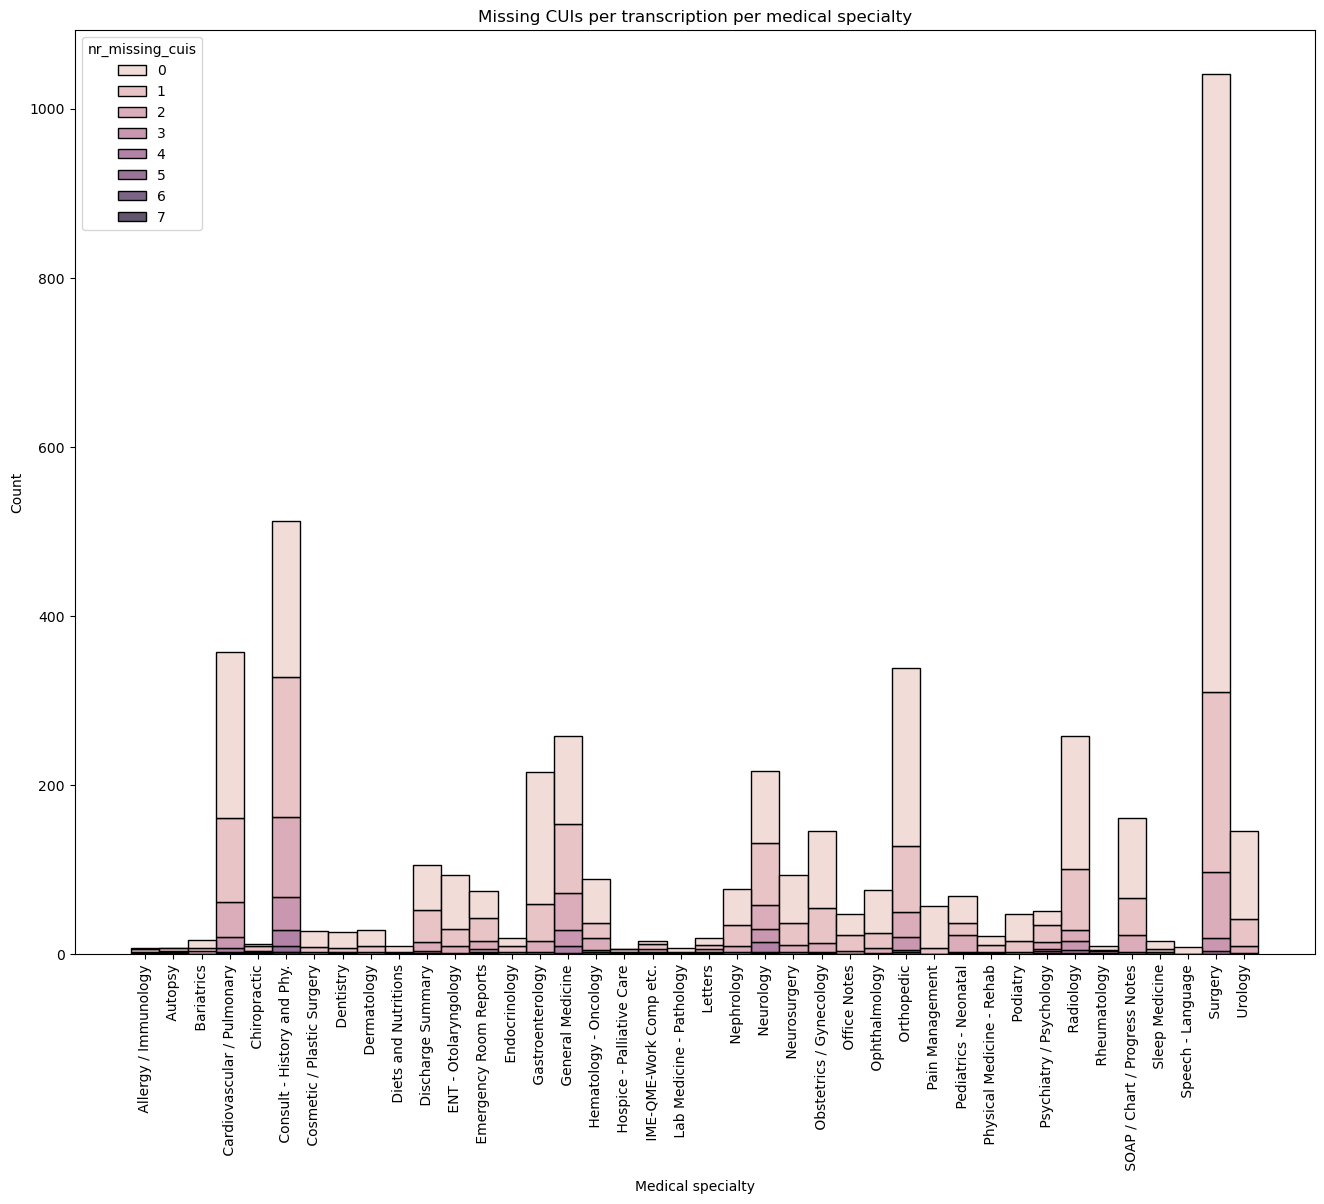

In [40]:
fig, ax = plt.subplots(figsize=(16,12))
sns.histplot(data=transcriptions_df, x='medical_specialty', multiple='stack', hue='nr_missing_cuis')
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Medical specialty')
ax.set_title("Missing CUIs per transcription per medical specialty")
plt.show()

Overall, we can see that CUIs are missing from all specialties. Let's see how many transcriptions have no CUI embedding per medical specialty.

In [41]:
transcriptions_df[transcriptions_df.length_embeddings == 0].groupby('medical_specialty')['CUI'].count()


/var/folders/h3/nfz97p4s4nbfn9k6j6f6cknh0000gn/T/ipykernel_2422/1434397396.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  transcriptions_df[transcriptions_df.length_embeddings == 0].groupby('medical_specialty')['CUI'].count()


medical_specialty
Allergy / Immunology             0
Autopsy                          0
Bariatrics                       0
Cardiovascular / Pulmonary       2
Chiropractic                     0
Consult - History and Phy.       1
Cosmetic / Plastic Surgery       0
Dentistry                        0
Dermatology                      0
Diets and Nutritions             0
Discharge Summary                0
ENT - Otolaryngology             1
Emergency Room Reports           0
Endocrinology                    0
Gastroenterology                 0
General Medicine                 0
Hematology - Oncology            1
Hospice - Palliative Care        0
IME-QME-Work Comp etc.           1
Lab Medicine - Pathology         0
Letters                          0
Nephrology                       0
Neurology                        1
Neurosurgery                     0
Obstetrics / Gynecology          1
Office Notes                     0
Ophthalmology                    0
Orthopedic                       2
Pa

Overall, there is a very small number of transcripts with no embeddings, so we can safely drop those data points from the dataset.

In [42]:
transcriptions_df_copy = transcriptions_df.copy()

transcriptions_df = transcriptions_df[transcriptions_df.length_embeddings > 0]
transcriptions_df.shape

(4766, 9)

## 6. Classification – Medical specialties

### Feature engineering

At this point, we have extracted the entities from the transcription text, lined each entity to its best match in UMLS and found the cui2vec embeddings of most available CUIs. The goal of this exercise is to train a classifier that predicts the medical specialty needed by a patient based on the transcript (complaints and medical history).

We will use the embeddings to train the classifier. As a first attempt, let's calculate the average embedding vector per data point - but first let's drop unecessary columns from the dataset.

In [43]:
cols_to_keep = ['medical_specialty', 'embeddings']
transcriptions_df = transcriptions_df[cols_to_keep]

transcriptions_df.head()


,medical_specialty,embeddings
0,Allergy / Immunology,"[[-2.78627139416676e-05, 8.00991277900353e-06,..."
1,Bariatrics,"[[-3.43515510058972, 2.49043619512159, 9.32587..."
2,Bariatrics,"[[-3.43515510058972, 2.49043619512159, 9.32587..."
3,Cardiovascular / Pulmonary,"[[-0.0262371402549892, 0.009309302154966, 1.73..."
4,Cardiovascular / Pulmonary,"[[-0.0499092522583929, 0.0289295602458864, -1...."


In [44]:
transcriptions_df['average_embedding'] = transcriptions_df.embeddings.apply(lambda x: np.mean(x, axis=0))

transcriptions_df.head()

,medical_specialty,embeddings,average_embedding
0,Allergy / Immunology,"[[-2.78627139416676e-05, 8.00991277900353e-06,...","[-0.004540039881680944, 0.0019219078392686201,..."
1,Bariatrics,"[[-3.43515510058972, 2.49043619512159, 9.32587...","[-2.808507352985719, 0.19975762751803242, 1.09..."
2,Bariatrics,"[[-3.43515510058972, 2.49043619512159, 9.32587...","[-2.4680262404143747, 0.2270888248601637, 3.77..."
3,Cardiovascular / Pulmonary,"[[-0.0262371402549892, 0.009309302154966, 1.73...","[-0.0207770460589052, 0.0112068351123844, -1.4..."
4,Cardiovascular / Pulmonary,"[[-0.0499092522583929, 0.0289295602458864, -1....","[-0.049674654210624676, 0.025785602370771127, ..."


As mentioned earlier, the dataset contains 40 medical specialties, and some of them are uncommon within the dataset. Additionally, the most common medical specialty ("Surgery") is almost 25% of the dataset, thus the dataset is very imbalanced, with more than half the categories having only a hanful of samples. 

Categories with fewer than 50 samples (roughly 1% of the dataset) were removed because they do not contain enough examples to train a reliable classifier. These extremely small classes create noise, destabilize cross-validation, and distort performance metrics. This threshold is aligned with standard practice in statistical learning.

Below, the minimum number of samples is set to 60. This is because, later, the train set will consist of 80% of the dataset, and to make sure we have roughly 50 samples per medical specialty, I se the limit to 60 (which gives a minimum of 48 samples in the train set).

Another reason for removing very small classes is that small classes cause over- and under- sampling of the train set (later) to fail.

In [45]:
num_samples = 60
num_specialties = sum((transcriptions_df.medical_specialty.value_counts() > num_samples))

top_specialties = transcriptions_df.medical_specialty.value_counts()[:num_specialties].index
num_class = top_specialties.shape[0]

transcriptions_sub_df = transcriptions_df[transcriptions_df.medical_specialty.isin(top_specialties)].reset_index(drop=True)

# medical_specialty should be of 'category' type
transcriptions_sub_df.medical_specialty = transcriptions_sub_df.medical_specialty.astype("category")

In [46]:
# Remove the categories that are not in the dataset any more
transcriptions_sub_df.medical_specialty.cat.remove_unused_categories()
transcriptions_sub_df.head()

,medical_specialty,embeddings,average_embedding
0,Cardiovascular / Pulmonary,"[[-0.0262371402549892, 0.009309302154966, 1.73...","[-0.0207770460589052, 0.0112068351123844, -1.4..."
1,Cardiovascular / Pulmonary,"[[-0.0499092522583929, 0.0289295602458864, -1....","[-0.049674654210624676, 0.025785602370771127, ..."
2,Cardiovascular / Pulmonary,"[[-0.0621735270826164, 0.025677338329708, -1.0...","[-0.05604138967050465, 0.027303449287797203, -..."
3,Cardiovascular / Pulmonary,"[[-0.0538841206650366, 0.0239611502400805, 2.2...","[-0.05132296296602381, 0.022356728566420934, 7..."
4,Neurology,"[[-0.0450356380516796, 0.0217953654097186, -3....","[-0.7706396179091162, 0.15541818734334445, -2...."


In [47]:
transcriptions_sub_df.shape

(4310, 3)

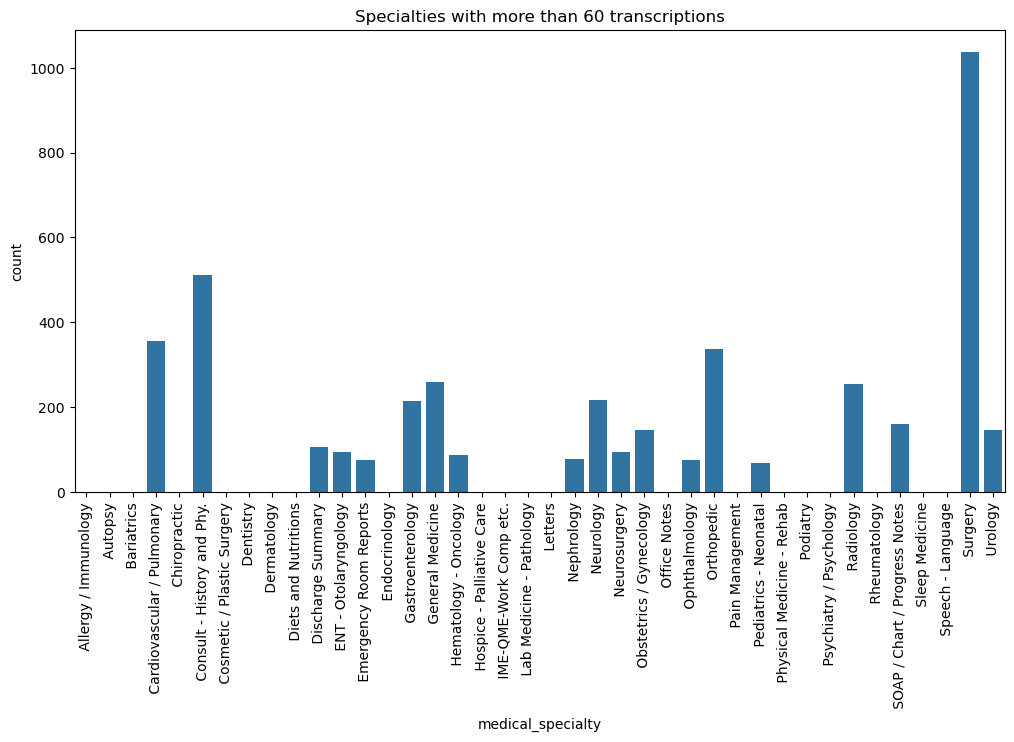

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(data=transcriptions_sub_df, x="medical_specialty", ax=ax)
ax.tick_params(axis='x', labelrotation=90)
ax.set_title(f"Specialties with more than {num_samples} transcriptions")
plt.show()

### Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder

# The labels have to be encoded as numbers
le = LabelEncoder()

X = transcriptions_sub_df['average_embedding'].to_list()
X = np.array(X, dtype=np.float32)
y = le.fit_transform(transcriptions_sub_df.medical_specialty)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

In [50]:
X_train, y_train

(array([[-1.4545733e+00,  3.6344233e-01,  1.6604032e-15, ...,
          6.4934664e-03, -9.3337208e-02,  4.4735298e-02],
        [-3.0640941e+00,  1.2655935e+00, -3.0535470e-15, ...,
         -6.0518380e-02,  9.7703456e-04, -1.3203904e-01],
        [-2.0763505e+00,  4.6649301e-01, -6.7263903e-16, ...,
         -3.1745937e-01, -6.6185296e-02, -6.8481940e-01],
        ...,
        [-1.0463723e+00, -1.1702182e+00,  3.5640436e-16, ...,
         -5.5512577e-02,  5.0126340e-02,  1.1332568e-02],
        [-1.1842477e+00,  4.4357911e-01,  7.5146053e-16, ...,
         -1.5343586e-02, -3.1745698e-02, -2.8641328e-02],
        [-3.8370952e-02,  1.3512212e-02, -1.6566609e-16, ...,
          1.0173255e-01,  8.0613559e-03, -5.8272403e-02]],
       shape=(3448, 500), dtype=float32),
 array([ 6,  6,  1, ..., 13, 17, 13], shape=(3448,)))

Since the dataset is so imbalanced, let's undersample the majority class ('Surgery') and oversample the remaining classes.

In [51]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# define pipeline
over = SMOTE(sampling_strategy="not majority", random_state=0)
under = RandomUnderSampler(sampling_strategy="majority", random_state=0)

### Baseline model

As a baseline model, we will use a very simple model that predicts the medical specialty of a sample randomly, based on the probability of each specialty in the training dataset. For this, I use the DumyClassifier class of scikit_learn

In [52]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import recall_score, f1_score, classification_report

strategy = 'stratified'

baseline_cls = DummyClassifier(strategy=strategy)    
baseline_cls.fit(X_train, y_train)

y_pred = baseline_cls.predict(X_test)
cr = classification_report(y_test, y_pred, output_dict=True)
print(pd.DataFrame(cr))

f1_score_baseline = cr['weighted avg']['f1-score']


                   0           1          2     3     4          5     6  \
precision   0.064103    0.141414   0.166667   0.0   0.0   0.019231   0.0   
recall      0.070423    0.137255   0.095238   0.0   0.0   0.023256   0.0   
f1-score    0.067114    0.139303   0.121212   0.0   0.0   0.021053   0.0   
support    71.000000  102.000000  21.000000  19.0  15.0  43.000000  52.0   

              7     8          9  ...    12         13    14         15    16  \
precision   0.0   0.0   0.029412  ...   0.0   0.101695   0.0   0.142857   0.0   
recall      0.0   0.0   0.023256  ...   0.0   0.089552   0.0   0.137255   0.0   
f1-score    0.0   0.0   0.025974  ...   0.0   0.095238   0.0   0.140000   0.0   
support    18.0  15.0  43.000000  ...  15.0  67.000000  14.0  51.000000  32.0   

                   17         18  accuracy   macro avg  weighted avg  
precision    0.231111   0.128205  0.109049    0.055526      0.105688  
recall       0.251208   0.172414  0.109049    0.054439      0.109049  


This classifier has really low accuracy, recall and f1 score. Next, let's train some advaced classifiers, to find the one that produces the best results for this use case.

### Train selected classification models

I will now train a few "traditional" ML models. Initially, the default parameters will be used for training in a 5-fold cross validation. From those models, I will senect the three best performing models (based on f1 score on the test set), and run them using cross-validation and a grid search for best parameters, in order to select the model with the best average f1 score.

In [53]:
n_splits = 3
cv = StratifiedKFold(n_splits=n_splits, shuffle=True)
scoring = ['f1_macro']

classifier_names = [
    "LogisticRegression",
    "Linear SVM",
    "XGBoost",
    "Random Forest",
    "AdaBoost",
]

classifiers = [
    LogisticRegression(class_weight="balanced"),
    SVC(random_state=0,class_weight='balanced', kernel='linear'),
    XGBClassifier(num_class=num_class, eval_metric="mlogloss"),
    RandomForestClassifier(class_weight='balanced', random_state=0),
    AdaBoostClassifier(random_state=0),
]

CV_scores = {}

for classifier_name, classifier in zip(classifier_names, classifiers):
    print(f"Classifier: {classifier_name} \n")
    steps = [('o', over), ('u', under)]

    pipeline = Pipeline(steps=steps.append(classifier))

    cv_score = cross_validate(
        classifier, X_train, y_train, cv=cv, scoring=scoring
    )
    CV_scores[classifier_name] = cv_score


Classifier: LogisticRegression 

Classifier: Linear SVM 

Classifier: XGBoost 

Classifier: Random Forest 

Classifier: AdaBoost 



In [54]:
CV_scores

{'LogisticRegression': {'fit_time': array([0.32610822, 0.28640604, 0.33781409]),
  'score_time': array([0.00162196, 0.002671  , 0.00144792]),
  'test_f1_macro': array([0.2775097 , 0.27333102, 0.26841837])},
 'Linear SVM': {'fit_time': array([0.58893514, 0.55146003, 0.57458377]),
  'score_time': array([0.17401195, 0.17505789, 0.17604208]),
  'test_f1_macro': array([0.25100162, 0.25498319, 0.27601219])},
 'XGBoost': {'fit_time': array([14.61746097, 14.02934313, 13.85371184]),
  'score_time': array([0.00599813, 0.00493693, 0.00634694]),
  'test_f1_macro': array([0.12211091, 0.1109383 , 0.135293  ])},
 'Random Forest': {'fit_time': array([3.19535375, 3.21142602, 3.24772406]),
  'score_time': array([0.01548028, 0.01579714, 0.01523209]),
  'test_f1_macro': array([0.10194342, 0.13021172, 0.10843716])},
 'AdaBoost': {'fit_time': array([4.76742125, 4.72777796, 4.86918402]),
  'score_time': array([0.008775  , 0.00879598, 0.00906587]),
  'test_f1_macro': array([0.08824259, 0.10416005, 0.09407009]

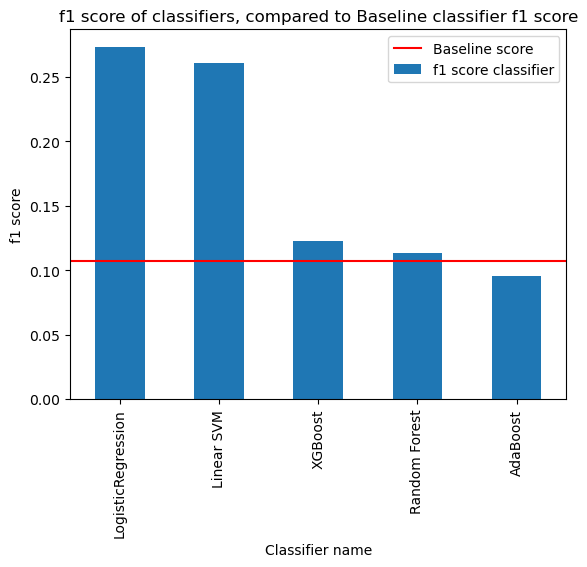

In [55]:
def get_score_df(score_dict, scores_list):
    d = {}
    for score in scores_list:
        if score in score_dict.keys():
            d[score] = score_dict[score].mean()
    return d

dd = {}
for m in CV_scores.keys(): 
    dd[m] = get_score_df(CV_scores[m], ['test_f1_macro'])

df = pd.DataFrame(dd)

fig, ax = plt.subplots()
df.T.test_f1_macro.plot.bar(label='f1 score classifier')
plt.axhline(y=f1_score_baseline, color='r', label='Baseline score')
plt.ylabel('f1 score')
plt.xlabel('Classifier name')
plt.title('f1 score of classifiers, compared to Baseline classifier f1 score')
plt.legend()
plt.show()

In [56]:
df.T

,test_f1_macro
LogisticRegression,0.273086
Linear SVM,0.260666
XGBoost,0.122781
Random Forest,0.113531
AdaBoost,0.095491


All classifiers, apart from AdaBoost, perform better than the baseline. The best performing classifiers are LogisticRegression and Linear SVC.

It should be noted that f1-macro is quite low (0.27), but it is a big improvement, compared to the naive baseline (0.08). The reason for this is the small dataset and the large number of classes. 

### Hyperparameter tuning and selection of best classifier

Now, I will search for optimal hyperparameters using cross validation and a grid of values of each of the top three performing classifiers above. The classifier with the highest f1 score wil be trained using the whole training dataset and its performance will be assessed on the test set.

In [59]:
import os
import pickle
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

params_grid = {
    "LogisticRegression": 
    {    
        "clf__C": [0.01, 0.1, 1, 10],
        "clf__penalty": ["l1", "l2"],
        "clf__solver": ["lbfgs", "saga"],  
    },
    
    "Linear SVM": 
    {
        "clf__C": [0.01, 0.1, 1, 10],
    },
}

hyperparameters_pickle_file = 'hyperparameters.pickle'
if os.path.exists(hyperparameters_pickle_file):
    with open('hyperparameters.pickle', 'rb') as handle:
        hparams = pickle.load(handle)

else:
    hparams = {}

    for classifier_name, classifier in zip(classifier_names, classifiers):
        if classifier_name in params_grid.keys():
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", classifier),
            ])
            print(pipeline)
            print(f'Classifier name: {classifier_name}')
            clf = GridSearchCV(
                estimator = pipeline,
                param_grid=params_grid[classifier_name],
                cv=cv,
                scoring=scoring,
                refit='f1_macro',
                verbose=True
            )
            clf.fit(X_train, y_train)
            hparams[classifier_name] = {
                'cv_results': clf.cv_results_,
                'best_estimator': clf.best_estimator_,
                'best_params': clf.best_params_,
                'best_score': clf.best_score_
            }
    with open('hyperparameters.pickle', 'wb') as handle:
        pickle.dump(hparams, handle, protocol=pickle.HIGHEST_PROTOCOL)
    

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(class_weight='balanced'))])
Classifier name: LogisticRegression
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarni

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 SVC(class_weight='balanced', kernel='linear',
                     random_state=0))])
Classifier name: Linear SVM
Fitting 3 folds for each of 4 candidates, totalling 12 fits


In [60]:
params_df = pd.DataFrame(hparams).T
params_df

,cv_results,best_estimator,best_params,best_score
LogisticRegression,"{'mean_fit_time': [0.010267972946166992, 5.278...","(StandardScaler(), LogisticRegression(C=0.1, c...","{'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__so...",0.279213
Linear SVM,"{'mean_fit_time': [0.6190377076466879, 0.62917...","(StandardScaler(), SVC(C=0.01, class_weight='b...",{'clf__C': 0.01},0.275871


In [61]:
best_estimator = params_df[params_df.best_score==params_df.best_score.max()].best_estimator.values[0]
print(best_estimator)
best_estimator.get_params()

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    penalty='l1', solver='saga'))])


{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('clf',
   LogisticRegression(C=0.1, class_weight='balanced', penalty='l1', solver='saga'))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'clf': LogisticRegression(C=0.1, class_weight='balanced', penalty='l1', solver='saga'),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'clf__C': 0.1,
 'clf__class_weight': 'balanced',
 'clf__dual': False,
 'clf__fit_intercept': True,
 'clf__intercept_scaling': 1,
 'clf__l1_ratio': None,
 'clf__max_iter': 100,
 'clf__multi_class': 'deprecated',
 'clf__n_jobs': None,
 'clf__penalty': 'l1',
 'clf__random_state': None,
 'clf__solver': 'saga',
 'clf__tol': 0.0001,
 'clf__verbose': 0,
 'clf__warm_start': False}

The improvement of the two classifiers is very small, compared to the classifier with default settings. The best performing classifier was Logistic Regression with L1 penalty, C=0.1 and 'sage' solver. 

### Train best classifier and make predictions on test set

Now, let's fit the train set on the best performing classifier and use the test set to assess the performance of the classifier on an not-seen-before dataset.

In [62]:
best_estimator.fit(X_train, y_train)
pred = best_estimator.predict(X_test)

print(classification_report(y_test, pred, target_names=le.classes_))

                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.38      0.48      0.42        71
    Consult - History and Phy.       0.52      0.14      0.22       102
             Discharge Summary       0.06      0.10      0.08        21
          ENT - Otolaryngology       0.28      0.68      0.39        19
        Emergency Room Reports       0.14      0.33      0.20        15
              Gastroenterology       0.35      0.47      0.40        43
              General Medicine       0.26      0.19      0.22        52
         Hematology - Oncology       0.21      0.50      0.30        18
                    Nephrology       0.20      0.53      0.29        15
                     Neurology       0.39      0.63      0.48        43
                  Neurosurgery       0.27      0.53      0.36        19
       Obstetrics / Gynecology       0.36      0.62      0.46        29
                 Ophthalmology       0.24      0.80      0.37  

/Users/mariakalimeri/opt/anaconda3/envs/analysis_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


The performance of the classifier is an improvement to the naive baseline classifier, with precision between 0.06 and 0.52, recall between 0.02 and 0.68 and f1-score between 0.03 and 0.42. 

It should be noted that larger sample size was important to higher performance, the classifier did not perform best on the larger sample (Surgery). Interestingly, the sample with the highest recall (Gyneacology) has a relatively small size.


## 9. Conclusion & Insights

The aim of this project was to investigate the capabilities of scispacy and cui2vec in text classification.

The classification performance achieved in this study is mainly limited by the nature of the data rather than by the choice of machine learning models. The dataset contains a relatively small number of documents spread across many imbalanced classes, and each document includes only a few extracted medical entities. As a result, the information available to distinguish between classes is limited, especially for rare categories, which leads to lower macro-F1 scores. Under these conditions, further tuning of classifiers alone is unlikely to lead to large improvements.

Meaningful gains can instead be achieved by improving how the documents are represented. Combining concept-level information (CUIs) with text-level embeddings from domain-specific language models such as BioClinicalBERT or PubMedBERT can provide richer context and better capture differences between classes. In addition, using more informative ways to aggregate entities and filtering out low-confidence extractions can reduce noise and preserve useful signals. While performance is constrained by fixed data size and class definitions, these steps offer a practical way to improve results without changing the dataset.

# 10. Future work
- Investigate BioClinicalBERT/PubMedBERT embeddings
- try different handling of embeddings (eg. Weighted means, get weighted mean per entity type)

## 11. Resources

[1] Beam AL, et al. “Clinical Concept Embeddings Learned from Massive Sources of Multimodal Medical Data.” (2018)
[2] https://figshare.com/s/00d69861786cd0156d81
